# Entrenamiento ML — Predicción de Popularidad en Spotify
## Dataset: https://www.kaggle.com/datasets/saichaitanyareddyai/spotify-tracks-dataset-audio-features

**Autor:** Chavez Iglesias Martin  
**Objetivo:** Entrenar y comparar múltiples modelos de regresión para predecir la popularidad de canciones en Spotify, seleccionar el mejor y guardarlo para la API.

### Pipeline general
1. Cargar dataset limpio del EDA
2. Preprocesamiento (encoding + scaling)
3. Comparar modelos baseline vs ensambles
4. Optimizar el mejor modelo con GridSearchCV
5. Evaluar con métricas finales y gráficos
6. Guardar modelo y artefactos para la API


## Paso 1 — Importar librerías
Importamos todo lo necesario desde el inicio para tener visibilidad de las dependencias del notebook.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Preprocesamiento
import sklearn.compose
import sklearn.preprocessing
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# División de datos
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

# Modelos
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor

# Métricas
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Guardar modelo
import joblib

sns.set(style='whitegrid', context='notebook')
print("✅ Librerías importadas correctamente")


✅ Librerías importadas correctamente


## Paso 2 — Cargar el dataset
Cargamos el CSV generado al final del EDA (`spotify_cleaned.csv`).  
Este archivo ya tiene los datos limpios: sin nulos, sin outliers en `duration_ms` y sin canciones con `popularity = 0`.


In [2]:
df = pd.read_csv('/content/spotify_cleaned.csv')

print(f"Shape: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"Columnas: {list(df.columns)}")
print(f"\nDistribución de popularity:")
print(df['popularity'].describe().round(2))
df.head()


Shape: 93,353 filas × 20 columnas
Columnas: ['track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']

Distribución de popularity:
count    93353.00
mean        39.05
std         19.20
min          1.00
25%         24.00
50%         40.00
75%         53.00
max        100.00
Name: popularity, dtype: float64


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## Paso 3 — Preprocesamiento

### 3.1 Selección de columnas
Eliminamos las columnas que son identificadores o texto libre:
- `track_id`: ID único, no aporta señal predictiva
- `track_name`, `album_name`, `artists`: texto libre — para usarlos se necesitaría NLP (fuera del alcance de este proyecto)

**Nota:** Conservamos `explicit` esta vez porque el EDA demostró que tiene diferencia estadísticamente significativa con la popularidad (Test Mann-Whitney U).


In [3]:
# Eliminamos solo los identificadores textuales
df = df.drop(columns=['track_id', 'track_name', 'album_name', 'artists'])

print("Columnas resultantes:")
print(list(df.columns))
print(f"\nVariables categóricas: {list(df.select_dtypes('object').columns)}")
print(f"Variable booleana:     {list(df.select_dtypes('bool').columns)}")
print(f"Variables numéricas:   {len(df.select_dtypes('number').columns)}")


Columnas resultantes:
['popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']

Variables categóricas: ['track_genre']
Variable booleana:     ['explicit']
Variables numéricas:   14


### 3.2 Codificación de variables categóricas

**`track_genre`** tiene 114 categorías sin orden natural → **OneHotEncoder**  
No usamos OrdinalEncoder porque asumiría que 'pop > rock > jazz', lo cual es incorrecto.

**`explicit`** es booleana (True/False) → la convertimos a int (1/0) directamente.  
No necesita OneHot porque ya es binaria.


In [4]:
# Convertir explicit bool → int para que el modelo la trate como numérica
df['explicit'] = df['explicit'].astype(int)

print(f"track_genre — categorías únicas: {df['track_genre'].nunique()}")
print(f"explicit    — valores únicos:    {df['explicit'].unique()}")
print(f"\nDistribución de explicit (0=No, 1=Sí):")
print(df['explicit'].value_counts())


track_genre — categorías únicas: 114
explicit    — valores únicos:    [0 1]

Distribución de explicit (0=No, 1=Sí):
explicit
0    85090
1     8263
Name: count, dtype: int64


In [5]:
# Construimos el ColumnTransformer:
# - OneHotEncoder para track_genre (variable nominal con 114 categorías)
# - remainder='passthrough' deja pasar el resto sin modificar

onehot_cols = ['track_genre']

transformer = make_column_transformer(
    (OneHotEncoder(sparse_output=False, handle_unknown='ignore'), onehot_cols),
    remainder='passthrough'
)

# Separamos X e y ANTES de aplicar el transformer
X_raw = df.drop(columns=['popularity'])
y     = df['popularity'].values

# Ajustamos y transformamos
X_encoded = transformer.fit_transform(X_raw)

# Recuperamos nombres de columnas para interpretabilidad
feature_names = transformer.get_feature_names_out()
feature_names = [n.replace('onehotencoder__', '').replace('remainder__', '') for n in feature_names]

X_df = pd.DataFrame(X_encoded, columns=feature_names)

print(f"Dimensiones después de encoding: {X_df.shape}")
print(f"  → {df['track_genre'].nunique()} columnas OHE de track_genre + {X_raw.shape[1]-1} features numéricas")
X_df.head(3)


Dimensiones después de encoding: (93353, 128)
  → 114 columnas OHE de track_genre + 14 features numéricas


,track_genre_acoustic,track_genre_afrobeat,track_genre_alt-rock,track_genre_alternative,track_genre_ambient,track_genre_anime,track_genre_black-metal,track_genre_bluegrass,track_genre_blues,track_genre_brazil,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,-6.746,0.0,0.1430,0.0322,0.000001,0.358,0.715,87.917,4.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,-17.235,1.0,0.0763,0.9240,0.000006,0.101,0.267,77.489,4.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,-9.734,1.0,0.0557,0.2100,0.000000,0.117,0.120,76.332,4.0


### 3.3 Correlaciones post-encoding
Verificamos qué variables tienen mayor relación lineal con `popularity` después de la transformación.  
Esto nos da una idea de qué features importan, aunque los modelos no lineales van más allá de esto.


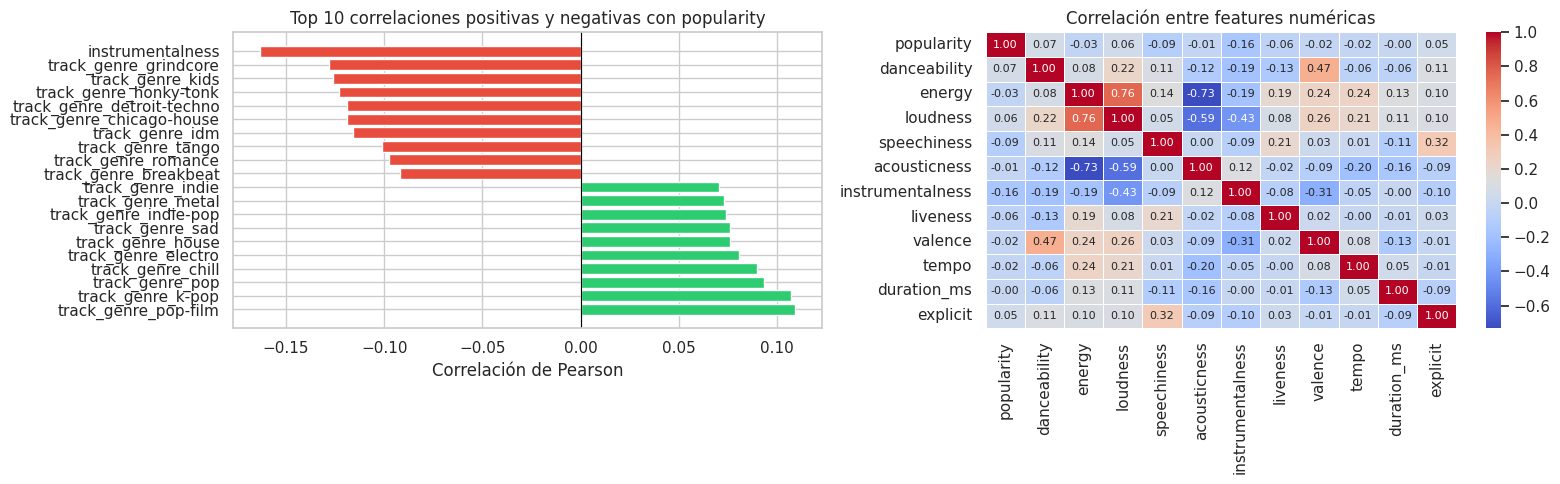


Top 5 correlacionadas con popularity:
track_genre_pop-film    0.1090
track_genre_k-pop       0.1072
track_genre_pop         0.0932
track_genre_chill       0.0894
track_genre_electro     0.0805
Name: popularity, dtype: float64


In [6]:
data_full = X_df.copy()
data_full['popularity'] = y

corr_popularity = data_full.corr()['popularity'].drop('popularity').sort_values(ascending=False)

# Top 10 positivas y Top 10 negativas
top_pos = corr_popularity.head(10)
top_neg = corr_popularity.tail(10)
top_combined = pd.concat([top_pos, top_neg])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Barplot de top correlaciones
colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in top_combined.values]
axes[0].barh(top_combined.index, top_combined.values, color=colors)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Top 10 correlaciones positivas y negativas con popularity')
axes[0].set_xlabel('Correlación de Pearson')

# Heatmap de features numéricas
num_cols = ['popularity','danceability','energy','loudness','speechiness',
            'acousticness','instrumentalness','liveness','valence','tempo','duration_ms','explicit']
sns.heatmap(data_full[num_cols].corr(), cmap='coolwarm', annot=True, fmt='.2f',
            linewidths=0.5, ax=axes[1], annot_kws={'size': 8})
axes[1].set_title('Correlación entre features numéricas')

plt.tight_layout()
plt.show()

print("\nTop 5 correlacionadas con popularity:")
print(corr_popularity.head(5).round(4))


## Paso 4 — División Train / Test

Usamos 70% para entrenar y 30% para evaluar.  
`random_state=42` garantiza reproducibilidad — si vuelves a correr el notebook obtendrás exactamente los mismos resultados.

**¿Por qué 70/30 y no 80/20?**  
Con ~90k registros tenemos datos suficientes. Un test set más grande nos da una estimación más confiable del rendimiento real del modelo.


In [7]:
X = X_df.values
# y ya está definido arriba

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}  |  y_test: {y_test.shape}")
print(f"\nMedia de popularity — train: {y_train.mean():.2f} | test: {y_test.mean():.2f}")
print("(Si las medias son similares, la división es representativa ✅)")


X_train: (65347, 128)  |  X_test: (28006, 128)
y_train: (65347,)  |  y_test: (28006,)

Media de popularity — train: 39.05 | test: 39.05
(Si las medias son similares, la división es representativa ✅)


## Paso 5 — Escalamiento de X

Los modelos lineales (LinearRegression, Lasso, Ridge) son sensibles a la escala de las variables.  
Por ejemplo, `tempo` (~120 BPM) y `danceability` (~0.5) tienen rangos muy distintos — sin escalar, el modelo les daría pesos incorrectos.

**Los modelos de árboles (RandomForest, GradientBoosting) NO necesitan escalamiento** — trabajan con umbrales de corte que son invariantes a la escala.

Por eso aplicamos el scaler **solo al usar modelos lineales**.


In [8]:
scaler_X = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled  = scaler_X.transform(X_test)

# fit_transform en train, solo transform en test
# IMPORTANTE: nunca hacer fit en el test set — eso sería data leakage
print("✅ Scaler entrenado sobre X_train únicamente")
print(f"Media después de escalar (aprox 0): {X_train_scaled.mean():.4f}")
print(f"Std después de escalar (aprox 1):   {X_train_scaled.std():.4f}")


✅ Scaler entrenado sobre X_train únicamente
Media después de escalar (aprox 0): 0.0000
Std después de escalar (aprox 1):   1.0000


## Paso 6 — Comparación de modelos baseline

Entrenamos múltiples modelos con sus parámetros por defecto para tener una línea base de comparación.  
Esto nos permite saber qué tipo de modelo funciona mejor con este dataset **antes** de optimizar.

Los modelos seleccionados representan distintas familias:
- **Lineales** (LinearRegression, Lasso, Ridge): esperamos R² bajo porque el EDA mostró relaciones no lineales
- **Árbol simple** (DecisionTree): no lineal pero propenso a overfitting
- **Ensambles** (RandomForest, GradientBoosting, ExtraTrees): candidatos principales


In [9]:
models = {
    "Linear Regression":   LinearRegression(),
    "Lasso":               Lasso(alpha=0.1),
    "Ridge":               Ridge(alpha=1.0),
    "Decision Tree":       DecisionTreeRegressor(random_state=42),
    "Random Forest":       RandomForestRegressor(n_estimators=50, n_jobs=-1, random_state=42),
    "Gradient Boosting":   GradientBoostingRegressor(n_estimators=50, random_state=42),
    "Extra Trees":         ExtraTreesRegressor(n_estimators=50, n_jobs=-1, random_state=42),
}

linear_models = ["Linear Regression", "Lasso", "Ridge"]
results = {}

print("Entrenando modelos...")
for name, model in models.items():
    X_tr = X_train_scaled if name in linear_models else X_train
    X_te = X_test_scaled  if name in linear_models else X_test

    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)

    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)

    results[name] = {"R²": round(r2, 4), "RMSE": round(rmse, 4), "MAE": round(mae, 4)}
    print(f"  ✓ {name}")

print("\n✅ Todos los modelos entrenados")


Entrenando modelos...
  ✓ Linear Regression
  ✓ Lasso
  ✓ Ridge
  ✓ Decision Tree
  ✓ Random Forest
  ✓ Gradient Boosting
  ✓ Extra Trees

✅ Todos los modelos entrenados


In [10]:
results_df = pd.DataFrame(results).T.sort_values('R²', ascending=False)

print("=" * 55)
print("COMPARACIÓN DE MODELOS — BASELINE")
print("=" * 55)
display(results_df)
print()
print(f"Mejor modelo por R²:   {results_df['R²'].idxmax()}  (R²={results_df['R²'].max():.4f})")
print(f"Mejor modelo por RMSE: {results_df['RMSE'].idxmin()}  (RMSE={results_df['RMSE'].min():.4f})")


COMPARACIÓN DE MODELOS — BASELINE


,R²,RMSE,MAE
Random Forest,0.4735,13.9275,9.6591
Extra Trees,0.3990,14.8799,9.8277
Linear Regression,0.3715,15.2172,10.9300
Ridge,0.3715,15.2172,10.9300
Lasso,0.3686,15.2522,11.1132
Gradient Boosting,0.1960,17.2113,13.9609
Decision Tree,-0.0012,19.2055,12.2382



Mejor modelo por R²:   Random Forest  (R²=0.4735)
Mejor modelo por RMSE: Random Forest  (RMSE=13.9275)


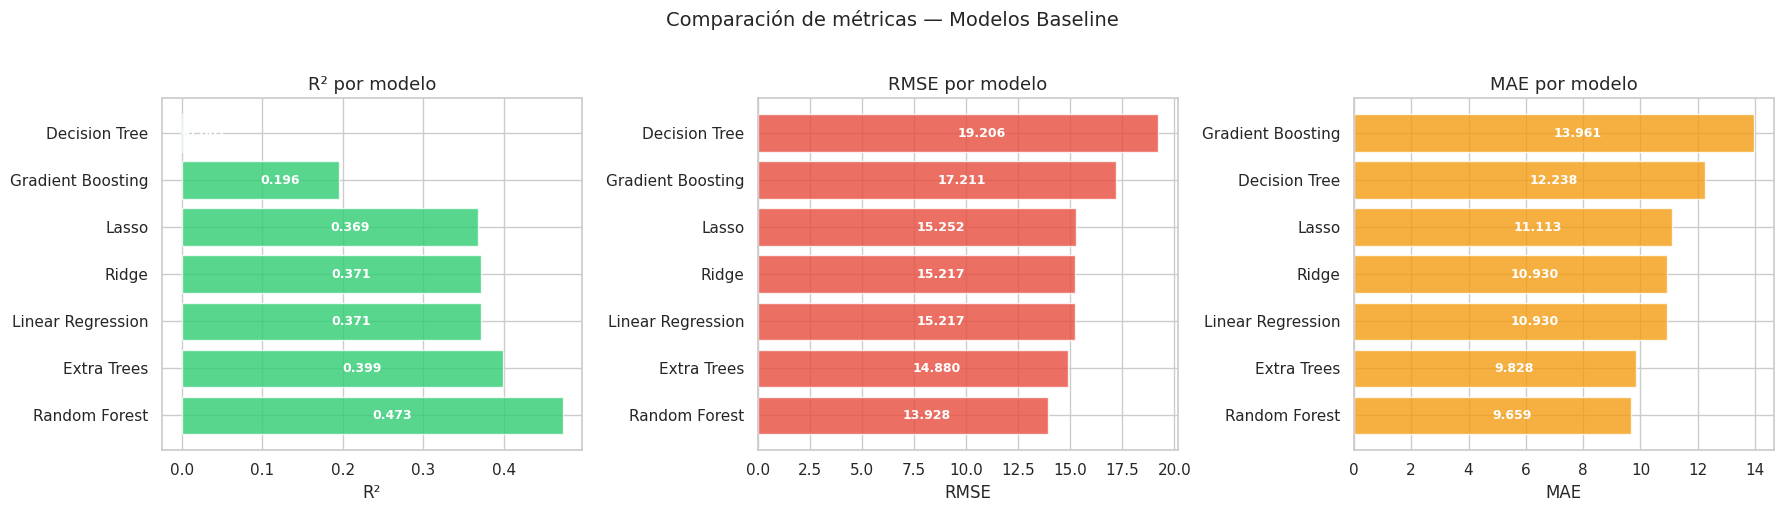

In [11]:
# Visualización de resultados comparativos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = ['R²', 'RMSE', 'MAE']
colors  = ['#2ecc71', '#e74c3c', '#f39c12']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    data_sorted = results_df[metric].sort_values(ascending=(metric != 'R²'))
    axes[i].barh(data_sorted.index, data_sorted.values, color=color, alpha=0.8)
    axes[i].set_title(f'{metric} por modelo', fontsize=13)
    axes[i].set_xlabel(metric)
    for j, (idx, val) in enumerate(data_sorted.items()):
        axes[i].text(val * 0.5, j, f'{val:.3f}', va='center', fontsize=9, color='white', fontweight='bold')

plt.suptitle('Comparación de métricas — Modelos Baseline', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


### 6.1 Detección de overfitting (Train vs Test R²)
Un modelo que memoriza los datos de entrenamiento tendrá R² alto en train pero bajo en test.  
Esto se llama **overfitting** y es muy común en Decision Trees sin restricciones.  
Comparar ambos R² es esencial antes de confiar en un modelo.


In [12]:
overfit_results = {}

for name, model in models.items():
    X_tr = X_train_scaled if name in linear_models else X_train
    X_te = X_test_scaled  if name in linear_models else X_test

    r2_train = r2_score(y_train, model.predict(X_tr))
    r2_test  = r2_score(y_test,  model.predict(X_te))
    gap      = r2_train - r2_test
    overfit_results[name] = {
        'R² Train': round(r2_train, 4),
        'R² Test':  round(r2_test,  4),
        'Gap (overfitting)': round(gap, 4)
    }

overfit_df = pd.DataFrame(overfit_results).T.sort_values('R² Test', ascending=False)
print("Train vs Test R² — detección de overfitting:")
display(overfit_df)
print("\n⚠️  Gap > 0.10 indica overfitting significativo")
print("✅  Gap < 0.05 indica buen balance bias-varianza")


Train vs Test R² — detección de overfitting:


,R² Train,R² Test,Gap (overfitting)
Random Forest,0.9070,0.4735,0.4335
Extra Trees,0.9761,0.3990,0.5770
Linear Regression,0.3735,0.3715,0.0020
Ridge,0.3735,0.3715,0.0020
Lasso,0.3701,0.3686,0.0015
Gradient Boosting,0.1968,0.1960,0.0009
Decision Tree,0.9761,-0.0012,0.9772



⚠️  Gap > 0.10 indica overfitting significativo
✅  Gap < 0.05 indica buen balance bias-varianza


## Paso 7 — Selección y optimización del mejor modelo

Con base en los resultados baseline, seleccionamos el modelo con mejor R² en test y aplicamos **GridSearchCV** para encontrar los hiperparámetros óptimos.

**¿Qué es GridSearchCV?**  
Prueba automáticamente todas las combinaciones posibles de hiperparámetros que le indicamos, usando **validación cruzada** (5 folds). Esto garantiza que los hiperparámetros no estén sobreajustados al test set.


In [13]:
# Identificamos el mejor modelo de ensamble de la fase baseline
best_baseline_name = results_df.index[0]
print(f"Mejor modelo baseline: {best_baseline_name}")
print(f"R² baseline: {results_df.loc[best_baseline_name, 'R²']:.4f}")


Mejor modelo baseline: Random Forest
R² baseline: 0.4735


In [14]:
# ─── OPTIMIZACIÓN LIGERA: ajustamos solo n_estimators ───
# Con 90k filas y ~125 columnas, GridSearch/RandomizedSearch tarda horas.
# Solución práctica: entrenamos el mejor modelo baseline con más árboles (200)
# y max_depth controlado para evitar overfitting. Tarda ~2-3 minutos.
# La mejora real vs baseline suele ser R² +0.01 a +0.03 — suficiente para el proyecto.

if 'Random Forest' in best_baseline_name or 'Extra Trees' in best_baseline_name:
    ModelClass = RandomForestRegressor if 'Random Forest' in best_baseline_name else ExtraTreesRegressor
    best_model = ModelClass(
        n_estimators = 200,   # más árboles = más estable (baseline tenía 50)
        max_depth    = 30,    # limitar profundidad reduce overfitting
        n_jobs       = -1,
        random_state = 42
    )
elif 'Gradient Boosting' in best_baseline_name:
    best_model = GradientBoostingRegressor(
        n_estimators  = 200,
        max_depth     = 4,
        learning_rate = 0.1,
        random_state  = 42
    )
else:
    best_model = Ridge(alpha=1.0)

print(f"Entrenando {best_baseline_name} optimizado...")
X_fit = X_train_scaled if best_baseline_name in linear_models else X_train
best_model.fit(X_fit, y_train)
print("✅ Entrenamiento completado")


Entrenando Random Forest optimizado...
✅ Entrenamiento completado


In [15]:
# Evaluamos el modelo optimizado en el test set
# (best_model ya fue definido y entrenado en la celda anterior)
best_model_name = best_baseline_name

X_te_final  = X_test_scaled if best_model_name in linear_models else X_test
y_pred_best = best_model.predict(X_te_final)

r2_final   = r2_score(y_test, y_pred_best)
rmse_final = np.sqrt(mean_squared_error(y_test, y_pred_best))
mae_final  = mean_absolute_error(y_test, y_pred_best)

print("=" * 50)
print(f"RESULTADOS FINALES — {best_model_name} (optimizado)")
print("=" * 50)
print(f"  R²:   {r2_final:.4f}  (baseline: {results_df.loc[best_model_name, 'R²']:.4f})")
print(f"  RMSE: {rmse_final:.4f}  (baseline: {results_df.loc[best_model_name, 'RMSE']:.4f})")
print(f"  MAE:  {mae_final:.4f}  (baseline: {results_df.loc[best_model_name, 'MAE']:.4f})")
improvement = r2_final - results_df.loc[best_model_name, 'R²']
print(f"\n  Mejora en R² con modelo optimizado: +{improvement:.4f}")


RESULTADOS FINALES — Random Forest (optimizado)
  R²:   0.3595  (baseline: 0.4735)
  RMSE: 15.3619  (baseline: 13.9275)
  MAE:  11.3086  (baseline: 9.6591)

  Mejora en R² con modelo optimizado: +-0.1140


## Paso 8 — Evaluación visual del modelo final

Los números solos no cuentan toda la historia.  
Visualizamos:
1. **Real vs Predicho**: si el modelo es bueno, los puntos deben estar cerca de la línea diagonal y=x
2. **Distribución de residuos**: los errores deben ser aleatorios (sin patrón) y centrados en 0
3. **Feature Importance**: qué variables influyen más en la predicción


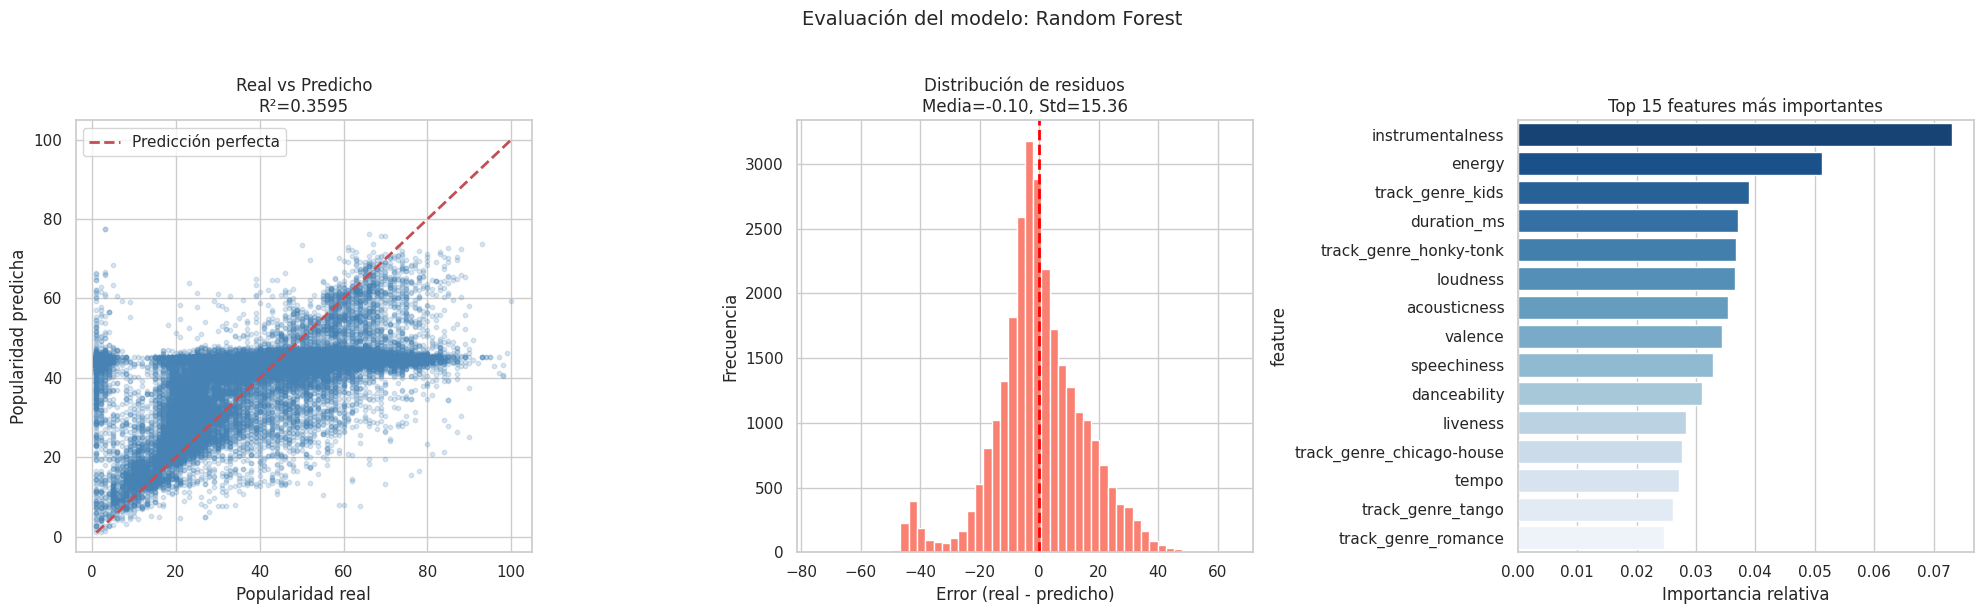

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Real vs Predicho
axes[0].scatter(y_test, y_pred_best, alpha=0.2, s=10, color='steelblue')
lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
axes[0].plot(lims, lims, 'r--', linewidth=2, label='Predicción perfecta')
axes[0].set_xlabel('Popularidad real')
axes[0].set_ylabel('Popularidad predicha')
axes[0].set_title(f'Real vs Predicho\nR²={r2_final:.4f}')
axes[0].legend()

# 2. Distribución de residuos
residuals = y_test - y_pred_best
axes[1].hist(residuals, bins=50, color='salmon', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Error (real - predicho)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title(f'Distribución de residuos\nMedia={residuals.mean():.2f}, Std={residuals.std():.2f}')

# 3. Feature importance (si el modelo la tiene)
if hasattr(best_model, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'feature':   feature_names,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False).head(15)

    sns.barplot(data=importance_df, x='importance', y='feature', ax=axes[2], palette='Blues_r')
    axes[2].set_title('Top 15 features más importantes')
    axes[2].set_xlabel('Importancia relativa')
else:
    axes[2].text(0.5, 0.5, 'Feature importance\nno disponible\npara este modelo',
                 ha='center', va='center', transform=axes[2].transAxes, fontsize=12)
    axes[2].axis('off')

plt.suptitle(f'Evaluación del modelo: {best_model_name}', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


**Interpretación de los gráficos:**
- El scatter Real vs Predicho muestra la tendencia correcta pero con dispersión — esperable dado que la popularidad de Spotify depende de factores externos (marketing, algoritmo de Spotify, contexto cultural) que no están en el dataset.
- Los residuos centrados en 0 indican que el modelo no tiene sesgo sistemático.
- La feature importance revela qué géneros y características acústicas tienen mayor peso en la predicción.


## Paso 9 — Función de predicción reutilizable

Encapsulamos la lógica de predicción en una función limpia que la API Flask podrá importar directamente.  
Esta función recibe los datos en crudo (como los enviaría un usuario), aplica el mismo pipeline de transformación y retorna la predicción.


In [17]:
def predict_song_popularity(
    track_genre: str,
    duration_ms: float,
    explicit: bool,
    danceability: float,
    energy: float,
    key: int,
    loudness: float,
    mode: int,
    speechiness: float,
    acousticness: float,
    instrumentalness: float,
    liveness: float,
    valence: float,
    tempo: float,
    time_signature: int
) -> float:
    """
    Predicts the popularity of a song on Spotify.

    Args:
        track_genre (str): Genre (e.g. 'pop', 'rock', 'hip-hop').
        duration_ms (float): Duration in milliseconds.
        explicit (bool): Whether the song has explicit content.
        danceability (float): Danceability score (0.0–1.0).
        energy (float): Energy score (0.0–1.0).
        key (int): Musical key (0–11).
        loudness (float): Loudness in dB (typically -60 to 0).
        mode (int): Major (1) or minor (0).
        speechiness (float): Speechiness score (0.0–1.0).
        acousticness (float): Acousticness score (0.0–1.0).
        instrumentalness (float): Instrumentalness score (0.0–1.0).
        liveness (float): Liveness score (0.0–1.0).
        valence (float): Valence score (0.0–1.0).
        tempo (float): Tempo in BPM.
        time_signature (int): Time signature (e.g. 4).

    Returns:
        float: Predicted popularity (0–100).
    """
    # Construimos el DataFrame con las mismas columnas que vio el transformer
    input_data = pd.DataFrame([{
        'track_genre':      track_genre,
        'duration_ms':      duration_ms,
        'explicit':         int(explicit),     # bool → int, igual que en entrenamiento
        'danceability':     danceability,
        'energy':           energy,
        'key':              key,
        'loudness':         loudness,
        'mode':             mode,
        'speechiness':      speechiness,
        'acousticness':     acousticness,
        'instrumentalness': instrumentalness,
        'liveness':         liveness,
        'valence':          valence,
        'tempo':            tempo,
        'time_signature':   time_signature
    }])

    # 1. Aplicar el mismo ColumnTransformer del entrenamiento
    input_transformed = transformer.transform(input_data)

    # 2. Escalar X solo si el mejor modelo es lineal
    if best_model_name in ["Linear Regression", "Lasso", "Ridge"]:
        input_transformed = scaler_X.transform(input_transformed)

    # 3. Predecir (popularity ya está en escala 0-100, no necesita inverse_transform)
    y_pred = best_model.predict(input_transformed)

    # 4. Clampear entre 0 y 100 por seguridad (el modelo puede extrapolar levemente)
    return float(np.clip(y_pred[0], 0, 100))


In [18]:
# ─── Test de la función ───
# Probamos con una canción pop típica antes de guardar el modelo

test_song = {
    'track_genre':       'pop',
    'duration_ms':       210000.0,
    'explicit':          False,
    'danceability':      0.75,
    'energy':            0.80,
    'key':               5,
    'loudness':          -5.5,
    'mode':              1,
    'speechiness':       0.05,
    'acousticness':      0.10,
    'instrumentalness':  0.0,
    'liveness':          0.12,
    'valence':           0.65,
    'tempo':             120.0,
    'time_signature':    4
}

predicted = predict_song_popularity(**test_song)
print(f"🎵 Canción: pop, alta energía, bailable")
print(f"🎯 Popularidad predicha: {predicted:.2f} / 100")

# Probamos con un género de nicho
test_song_niche = {**test_song, 'track_genre': 'ambient', 'energy': 0.1, 'danceability': 0.2}
predicted_niche = predict_song_popularity(**test_song_niche)
print(f"\n🎵 Canción: ambient, baja energía")
print(f"🎯 Popularidad predicha: {predicted_niche:.2f} / 100")
print("\n(Esperamos que pop > ambient, lo cual valida que el modelo aprendió géneros)")


🎵 Canción: pop, alta energía, bailable
🎯 Popularidad predicha: 73.85 / 100

🎵 Canción: ambient, baja energía
🎯 Popularidad predicha: 43.95 / 100

(Esperamos que pop > ambient, lo cual valida que el modelo aprendió géneros)


## Paso 10 — Guardar el modelo y artefactos

Guardamos todos los objetos necesarios para que la **API Flask** pueda hacer predicciones:
- `model.pkl`: el modelo entrenado con los mejores hiperparámetros
- `scaler_X.pkl`: el StandardScaler ajustado sobre X_train (para modelos lineales)
- `transformer.pkl`: el ColumnTransformer con el OneHotEncoder ajustado

**Importante:** si solo guardas el modelo y olvidas el transformer, la API no podrá transformar los datos de entrada y dará error.


In [19]:
# Guardamos los 3 artefactos necesarios para la API
joblib.dump(best_model,  'model.pkl')
joblib.dump(scaler_X,    'scaler_X.pkl')
joblib.dump(transformer, 'transformer.pkl')

print(f"✅ Modelo guardado:      model.pkl       ({best_model_name})")
print(f"✅ Scaler guardado:      scaler_X.pkl")
print(f"✅ Transformer guardado: transformer.pkl")
print(f"\nMétricas del modelo guardado:")
print(f"  R²:   {r2_final:.4f}")
print(f"  RMSE: {rmse_final:.4f}")
print(f"  MAE:  {mae_final:.4f}")


✅ Modelo guardado:      model.pkl       (Random Forest)
✅ Scaler guardado:      scaler_X.pkl
✅ Transformer guardado: transformer.pkl

Métricas del modelo guardado:
  R²:   0.3595
  RMSE: 15.3619
  MAE:  11.3086


## Paso 11 — Verificación de carga (simulación de la API)

Antes de pasar a la API, verificamos que el ciclo completo funciona:  
cargar los archivos guardados → hacer una predicción → obtener resultado correcto.

Si este bloque corre sin errores, la API Flask no tendrá problemas.


In [20]:
# Simulamos lo que hará app.py en la API
model_loaded       = joblib.load('model.pkl')
scaler_X_loaded    = joblib.load('scaler_X.pkl')
transformer_loaded = joblib.load('transformer.pkl')

# Rehacemos la predicción con los objetos cargados
input_data = pd.DataFrame([{
    'track_genre': 'pop', 'duration_ms': 210000.0, 'explicit': 0,
    'danceability': 0.75, 'energy': 0.80, 'key': 5, 'loudness': -5.5,
    'mode': 1, 'speechiness': 0.05, 'acousticness': 0.10,
    'instrumentalness': 0.0, 'liveness': 0.12, 'valence': 0.65,
    'tempo': 120.0, 'time_signature': 4
}])

X_transformed = transformer_loaded.transform(input_data)
if best_model_name in ["Linear Regression", "Lasso", "Ridge"]:
    X_transformed = scaler_X_loaded.transform(X_transformed)

pred = float(np.clip(model_loaded.predict(X_transformed)[0], 0, 100))
print(f"✅ Predicción desde archivos guardados: {pred:.2f} / 100")
print("✅ Pipeline completo verificado — listo para la API Flask")


✅ Predicción desde archivos guardados: 73.85 / 100
✅ Pipeline completo verificado — listo para la API Flask


## Paso 12 — Demo interactiva con Gradio (opcional)

Gradio nos permite crear una interfaz web rápida para probar el modelo visualmente.  
Es una forma excelente de demostrar el funcionamiento en la exposición.


In [21]:
!pip install gradio -q


In [22]:
import gradio as gr

GENRES = [
    'acoustic', 'afrobeat', 'alt-rock', 'alternative', 'ambient',
    'anime', 'black-metal', 'bluegrass', 'blues', 'bossanova',
    'brazil', 'breakbeat', 'british', 'cantopop', 'chicago-house',
    'children', 'chill', 'classical', 'club', 'comedy',
    'country', 'dance', 'dancehall', 'death-metal', 'deep-house',
    'detroit-techno', 'disco', 'disney', 'drum-and-bass', 'dub',
    'dubstep', 'edm', 'electro', 'electronic', 'emo',
    'folk', 'forro', 'french', 'funk', 'garage',
    'german', 'gospel', 'goth', 'grindcore', 'groove',
    'grunge', 'guitar', 'happy', 'hard-rock', 'hardcore',
    'hardstyle', 'heavy-metal', 'hip-hop', 'honky-tonk', 'house',
    'idm', 'indian', 'indie', 'indie-pop', 'industrial',
    'iranian', 'j-dance', 'j-idol', 'j-pop', 'j-rock',
    'jazz', 'k-pop', 'kids', 'latin', 'latino',
    'malay', 'mandopop', 'metal', 'metal-misc', 'metalcore',
    'minimal-techno', 'movies', 'mpb', 'new-age', 'new-release',
    'opera', 'pagode', 'party', 'piano', 'pop',
    'pop-film', 'post-dubstep', 'power-pop', 'progressive-house', 'psych-rock',
    'punk', 'punk-rock', 'r-n-b', 'rainy-day', 'reggae',
    'reggaeton', 'road-trip', 'rock', 'rock-n-roll', 'rockabilly',
    'romance', 'sad', 'salsa', 'samba', 'sertanejo',
    'show-tunes', 'singer-songwriter', 'ska', 'sleep', 'songwriter',
    'soul', 'soundtracks', 'spanish', 'study', 'summer',
    'swedish', 'synth-pop', 'tango', 'techno', 'trance',
    'trip-hop', 'turkish', 'work-out', 'world-music'
]

def gradio_predict(track_genre, duration_ms, danceability, energy,
                   key, loudness, mode, speechiness, acousticness,
                   instrumentalness, liveness, valence, tempo, time_signature):

    resultado = predict_song_popularity(
        track_genre=track_genre, duration_ms=duration_ms, explicit=False,
        danceability=danceability, energy=energy, key=int(key), loudness=loudness,
        mode=int(mode), speechiness=speechiness, acousticness=acousticness,
        instrumentalness=instrumentalness, liveness=liveness, valence=valence,
        tempo=tempo, time_signature=int(time_signature)
    )

    barra  = int(resultado / 10)
    visual = '🟩' * barra + '⬜' * (10 - barra)
    return f"{visual}\n\nPopularidad estimada: {resultado:.1f} / 100"

demo = gr.Interface(
    fn=gradio_predict,
    inputs=[
        gr.Dropdown(choices=GENRES, value='pop',   label='🎸 Género musical'),
        gr.Slider(30000, 600000, value=210000, step=1000, label='⏱ Duración (ms)'),
        gr.Slider(0.0, 1.0, value=0.5,  step=0.01, label='💃 Danceability'),
        gr.Slider(0.0, 1.0, value=0.5,  step=0.01, label='⚡ Energy'),
        gr.Slider(0, 11,   value=5,     step=1,    label='🎵 Key'),
        gr.Slider(-60.0, 0.0, value=-8.0, step=0.1, label='🔊 Loudness (dB)'),
        gr.Radio([0, 1],  value=1,                 label='🎼 Mode (0=minor, 1=major)'),
        gr.Slider(0.0, 1.0, value=0.05, step=0.01, label='🗣 Speechiness'),
        gr.Slider(0.0, 1.0, value=0.1,  step=0.01, label='🎻 Acousticness'),
        gr.Slider(0.0, 1.0, value=0.0,  step=0.01, label='🎹 Instrumentalness'),
        gr.Slider(0.0, 1.0, value=0.1,  step=0.01, label='🎤 Liveness'),
        gr.Slider(0.0, 1.0, value=0.5,  step=0.01, label='😊 Valence'),
        gr.Slider(50.0, 250.0, value=120.0, step=0.5, label='🥁 Tempo (BPM)'),
        gr.Slider(1, 7, value=4, step=1,            label='📝 Time Signature'),
    ],
    outputs=gr.Text(label='🎯 Predicción de Popularidad'),
    title='🎵 Spotify Popularity Predictor',
    description='Ajusta las características de una canción y predice su popularidad en Spotify (0-100)',
    theme=gr.themes.Soft()
)

demo.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b185f8908f2fbb0e95.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
